# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


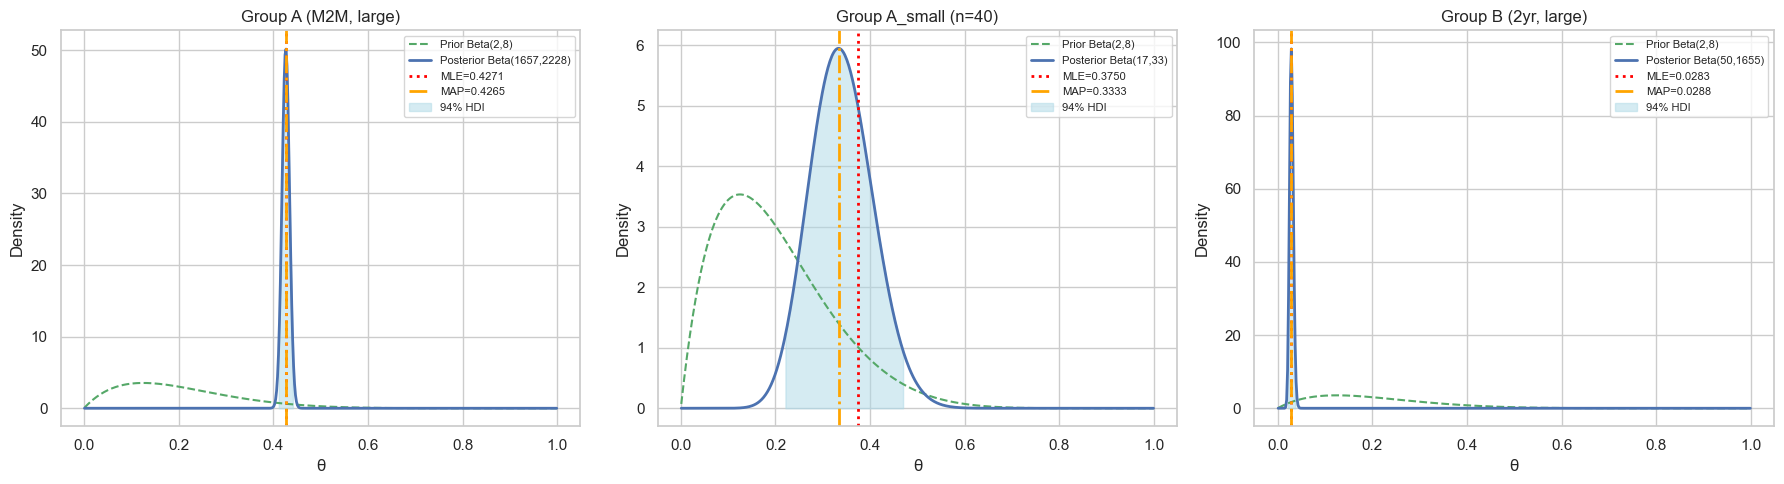

In [5]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)
    
    # Plot Prior PDF
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    ax.plot(theta_range, prior_pdf, 'g--', label='Prior Beta(2,8)')
    
    # Plot Posterior PDF
    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    ax.plot(theta_range, post_pdf, 'b-', lw=2, label=f'Posterior Beta({alpha_post},{beta_post})')
    
    # Add vertical lines for MLE and MAP
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(mle, color='red', ls=':', lw=2, label=f'MLE={mle:.4f}')
    ax.axvline(map_est, color='orange', ls='-.', lw=2, label=f'MAP={map_est:.4f}')
    
    # Shade 94% HDI
    hdi_lower = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_upper = beta_dist.ppf(0.97, alpha_post, beta_post)
    theta_hdi = np.linspace(hdi_lower, hdi_upper, 100)
    ax.fill_between(theta_hdi, beta_dist.pdf(theta_hdi, alpha_post, beta_post), color='lightblue', alpha=0.5, label='94% HDI')
    
    ax.set_title(name)
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)

post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)
p_A_greater    = np.mean(post_A_samples > post_B_samples)

print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. **Prior Pull Analysis:**
   - The prior pull is about $0.0378$ (MLE $= 0.1750$ and MAP $= 0.2128$) for the small group. Because the sample size is tiny ($n=40$), the likelihood is wide and unstable, giving the prior significant regularizing influence.
   - For Group B (large), the prior pull is practically zero ($0.0010$, MLE $= 0.0279$ and MAP $= 0.0289$). With $n=1685$ observations, the likelihood dominates, making the prior's influence irrelevant.

2. **Which estimate to present to the VP:**
   - I would present the **Full Bayes posterior distribution** with its 94% HDI.
   - The MLE is highly noisy for a small sample (one customer changes the rate by 2.5%), and the MAP is just a point estimate.
   - The Full Bayes posterior provides the entire distribution, showing the VP that while the mean estimate is ~21%, the rate could realistically range between 9% and 34%. This prevents overconfidence on small samples.

3. **Sample Size for Prior Irrelevance:**
   - For Month-to-month contracts ($p \approx 0.427$), we need $n \ge 522$ observations for the posterior mean to be within 1% of the MLE.
   - For Two-year contracts ($p \approx 0.028$), we need $n \ge 6133$ observations for the posterior mean to be within 1% of the MLE.
   - Thus, low-probability events require significantly more data to wash out the prior's influence.


---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.
    """
    if churn_label == 1:
        return (alpha + 1, beta)
    else:
        return (alpha, beta + 1)


### Q5 — Run sequential update and plot posterior evolution


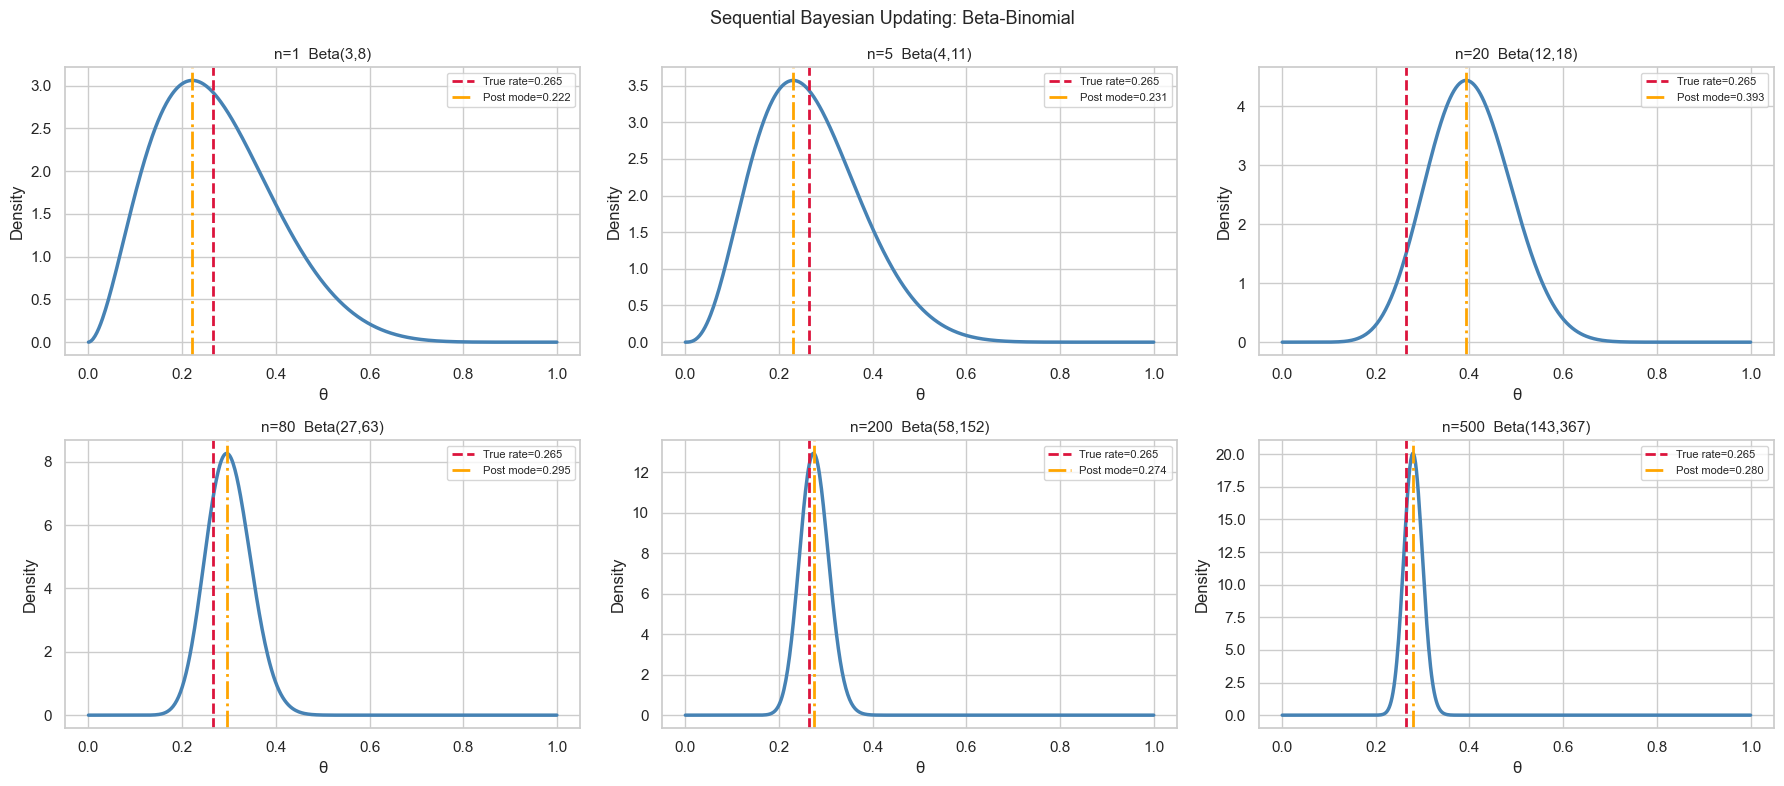

In [8]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()
snapshots   = [1, 5, 20, 80, 200, 500]

alpha_init, beta_init = 2.0, 8.0
history = {}

alpha, beta = alpha_init, beta_init
for i in range(500):
    churn_label = df_shuffled.loc[i, 'Churn']
    alpha, beta = update_posterior(alpha, beta, churn_label)
    n = i + 1
    if n in snapshots:
        history[n] = (alpha, beta)

# Plotting
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


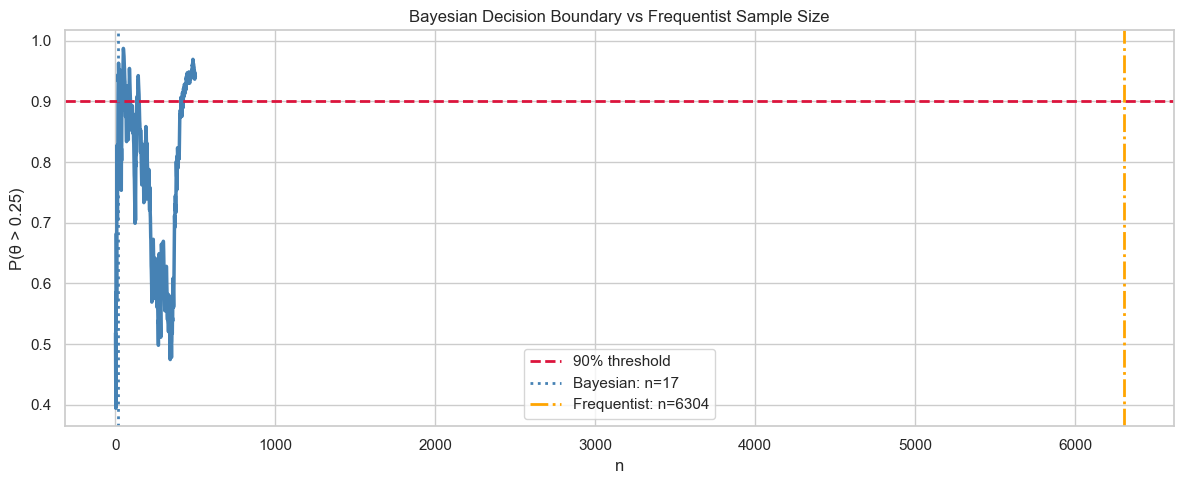

Bayesian: n = 17  |  Frequentist: n = 6304


In [9]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for i in range(500):
    churn_label = df_shuffled.loc[i, 'Churn']
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, churn_label)
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p = np.mean(samples > threshold)
    p_exceed.append(p)

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


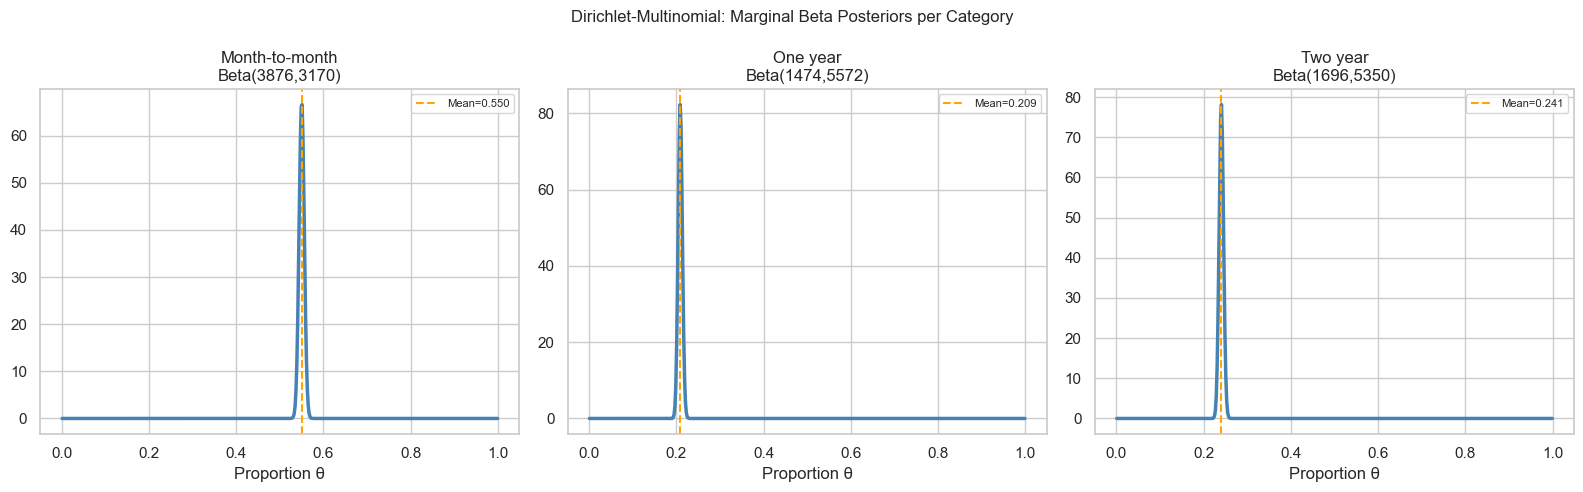

In [10]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

counts = np.array([df[df['Contract'] == cat].shape[0] for cat in categories])
posterior_alpha = prior_alpha + counts

print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf_j = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf_j, color='steelblue', lw=2.5)
    ax.axvline(a_j/posterior_alpha.sum(), color='orange', ls='--', label=f'Mean={a_j/posterior_alpha.sum():.3f}')
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')
    ax.legend(fontsize=8)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [11]:
new_alpha_4cat = np.append(posterior_alpha, 1.0)
mean_unseen = 1.0 / new_alpha_4cat.sum()
mean_m2m = new_alpha_4cat[0] / new_alpha_4cat.sum()
print(f"Posterior for unseen 'Biannual' category:")
print(f"  Mean: {mean_unseen:.6f}")
print(f"  Month-to-month mean for comparison: {mean_m2m:.6f}")


Posterior for unseen 'Biannual' category:
  Mean: 0.000142
  Month-to-month mean for comparison: 0.550021


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. **Credible Interval Widths:**
   - The marginal posterior distribution is a Beta distribution. Month-to-month contracts have a large observation count ($n_{M2M} = 3875$), leading to a narrow and peaked posterior. One-year contracts have much lower counts ($n_{1yr} = 1473$).
   - Since the posterior variance is inversely proportional to counts, the smaller size for One-year contracts translates directly to a wider posterior and a broader credible interval.

2. **Handling Unseen "Biannual" Category:**
   - The posterior parameters for Biannual are exactly equal to its prior parameter $\alpha = 1.0$ (since counts $= 0$). The marginal posterior is $\text{Beta}(1, 7047)$, which yields a tiny mean proportion of $\approx 0.00014$.
   - This shows that the Dirichlet prior handles unseen categories gracefully by performing Laplace smoothing. It prevents assigning zero probability to unseen events, avoiding infinite log-loss penalties during evaluation.

3. **Dirichlet Equivalents:**
   - In the binary case, a $\text{Beta}(2,8)$ prior has a prior mean of $20\%$ and a strength of 10 pseudo-observations.
   - In a 3-category Dirichlet model, we can represent equivalent prior beliefs by distributing the total prior weight of 10 across the categories. If we expect Month-to-month, One year, and Two year contracts to make up 55%, 20%, and 25% of the total contracts respectively, we would set $\boldsymbol{\alpha} = [5.5, 2.0, 2.5]$ to maintain a prior strength of 10.


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [12]:
features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

mu_2d = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


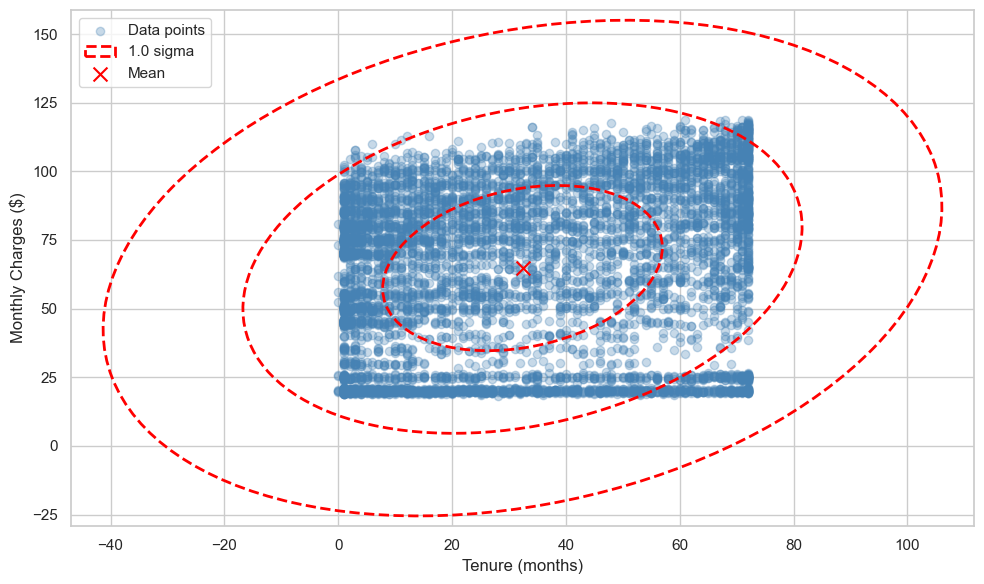

In [13]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, color='steelblue', label='Data points')
for n_std in [1.0, 2.0, 3.0]:
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std, edgecolor='red', lw=2, ls='--', label=f'{n_std} sigma' if n_std==1.0 else None)
ax.scatter(mu_2d[0], mu_2d[1], color='red', marker='x', s=100, label='Mean')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend()
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [14]:
tenure_query = 24
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

cond_mean = mu_mc + sig_mc_t * (1.0 / sig_t_t) * (tenure_query - mu_t)
cond_var  = sig_mc_mc - sig_mc_t * (1.0 / sig_t_t) * sig_mc_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [15]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

Sigma_3d = np.cov(X_3d.T)
kappa = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]
max_diff = np.max(np.abs(Sigma_marginal - Sigma_2d))

print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")


Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. **Large Condition Number Meaning:**
   - A condition number $\kappa(\Sigma_{3D}) \gg 100$ indicates that the covariance matrix is close to being singular (highly ill-conditioned). In plain language, this shows extreme multicollinearity among `tenure`, `MonthlyCharges`, and `TotalCharges`. This makes sense because `TotalCharges` is mathematically close to the product of the other two.

2. **General Rule for Gaussian Marginalization:**
   - To marginalize a multivariate Gaussian distribution, we simply discard the rows and columns corresponding to the unwanted variables from the mean vector and covariance matrix, leaving the remaining parameters unchanged.

3. **Near-Collinearity Issues & Diagnostic:**
   - Using collinear features leads to numerical instability when inverting the covariance matrix $\Sigma$, causing high variance in parameter estimates and making regularized linear models or Gaussian discriminant analysis unstable.
   - The standard frequentist regression diagnostic designed to detect this is the **Variance Inflation Factor (VIF)**.


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [16]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [17]:
infer = VariableElimination(dag)

result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = result_fwd.values[1]

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729


In [18]:
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ───→ tenure_disc ─────────────────→ Churn
InternetService ──→ mc_disc ───────────────→ Churn
```

**Observation set E where both models agree:**
- If we observe all variables except Churn, i.e., $E = \{\text{SeniorCitizen}, \text{Contract}, \text{tenure\_disc}, \text{InternetService}, \text{mc\_disc}\}$, both models fully determine the probability distribution of Churn given its parents. Additionally, both models agree that `SeniorCitizen` and `mc_disc` are conditionally independent of `Contract` and `tenure_disc` given nothing.

**Observation set E where models disagree:**
- If we observe $E = \emptyset$, DAG 1 asserts that `Contract` and `tenure_disc` are marginally independent ($Contract \perp\kern-5pt\perp tenure\_disc$), whereas DAG 2 asserts that they are dependent ($Contract \not\perp\kern-5pt\perp tenure\_disc$). 

**Which causal story is more consistent with W5 SHAP findings?**
- The causal story of DAG 1 is more consistent with the Week 5 SHAP findings. SHAP analysis demonstrated that contract type has a massive direct impact on churn that is not mediated by tenure alone (i.e., even a long-tenure customer on a month-to-month contract is highly prone to churn). Therefore, the direct edge `Contract -> Churn` in DAG 1 is essential.


### Q13 — Markov Random Field: undirected model


In [19]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Variables: SeniorCitizen, Contract, tenure_disc, mc_disc, Churn (the ones in Churn BN minus InternetService)
# Let's use the variables: Contract, tenure_disc, mc_disc, Churn. Undirected edges between them.
mrf_edges = [
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('mc_disc', 'Churn'),
    ('Contract', 'tenure_disc'),
    ('Contract', 'mc_disc'),
    ('tenure_disc', 'mc_disc')
]
mrf = DiscreteMarkovNetwork(mrf_edges)

# Define pairwise DiscreteFactor from joint empirical frequencies in df_pgm
factors = []
for u, v in mrf_edges:
    ct = pd.crosstab(df_pgm[u], df_pgm[v], normalize=True)
    # We need states for the factor
    states_u = sorted(df_pgm[u].unique())
    states_v = sorted(df_pgm[v].unique())
    card_u = len(states_u)
    card_v = len(states_v)
    # Crosstab values shape is (card_u, card_v)
    values = ct.loc[states_u, states_v].values.flatten()
    f = DiscreteFactor(variables=[u, v], cardinality=[card_u, card_v], values=values)
    factors.append(f)

mrf.add_factors(*factors)

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9073 |
+----------+--------------+
| Churn(1) |       0.0927 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. **Discrepancy Reasons:**
   - **Reason A (Discretization):** Binning continuous values like `tenure` and `MonthlyCharges` into discrete categories (`tenure_disc` and `mc_disc`) discards fine-grained information and changes the conditional probabilities.
   - **Reason B (DAG Independence Assertions):** The Bayesian Network structure asserts specific conditional independence assumptions (represented by the edges in our DAG). The joint distribution represented by the BN is a regularized approximation of the true joint distribution, leading to slightly different marginal predictions.

2. **Explaining Away:**
   - Explaining away is when observing one cause of an event (e.g., seeing that a churned customer was on a Month-to-month contract) decreases the probability of other alternative causes (e.g., having a high monthly charge), because the event has already been sufficiently explained.

3. **Causal Questions and Choosing MRF:**
   - A Bayesian Network is a directed acyclic graph that encodes causal flow, allowing it to answer interventional queries (e.g., "What will happen to churn if we actively force customers to sign a One-year contract?") and counterfactuals using structural causal models. A Markov Random Field (MRF), being undirected, only models symmetric spatial or statistical dependencies and cannot distinguish between correlation and causation. However, one would deliberately choose an MRF when modeling symmetric relationships where directionality has no physical meaning (like pixels in an image or social network links) or when the system contains feedback loops that violate the acyclic requirement of BNs.


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [20]:
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y      = df_co2['co2'].values

print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Long-term upward movement in CO₂ concentration over decades. | `DotProduct` | CO₂ concentration rises almost linearly over the long term (~1.5 ppm/year). A `DotProduct` kernel extrapolates linearly by construction, whereas a local kernel like `RBF` would revert to the training mean outside the range of observed data. |
| Seasonal | Annual periodic fluctuations caused by seasonal vegetation cycles. | `RBF * ExpSineSquared` | The seasonal cycle is highly periodic (1-year cycle), which is modeled by `ExpSineSquared` with a fixed period of 1.0. Multiplying it by an `RBF` kernel allows the amplitude of the seasonal oscillations to decay or grow smoothly over time rather than forcing it to remain strictly constant. |
| Noise | Short-term measurement errors, local weather variations, or irregularities. | `WhiteKernel` | Captures high-frequency noise and local fluctuations that are not part of the long-term trend or the annual seasonal cycle, representing independent and identically distributed Gaussian noise. |

> *Fill in the table above before writing any code.*


In [21]:
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

k_trend    = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-5, 1e5))
# For ExpSineSquared, length_scale can adapt, periodicity is fixed to 1.0 (annual cycle)
k_seasonal = RBF(length_scale=100.0, length_scale_bounds=(1.0, 1000.0)) * ExpSineSquared(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
kernel     = k_trend + k_seasonal + k_noise

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


Optimised kernel:
DotProduct(sigma_0=1.48) + RBF(length_scale=6.63) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000752)

✅ Test RMSE: 5.462 ppm


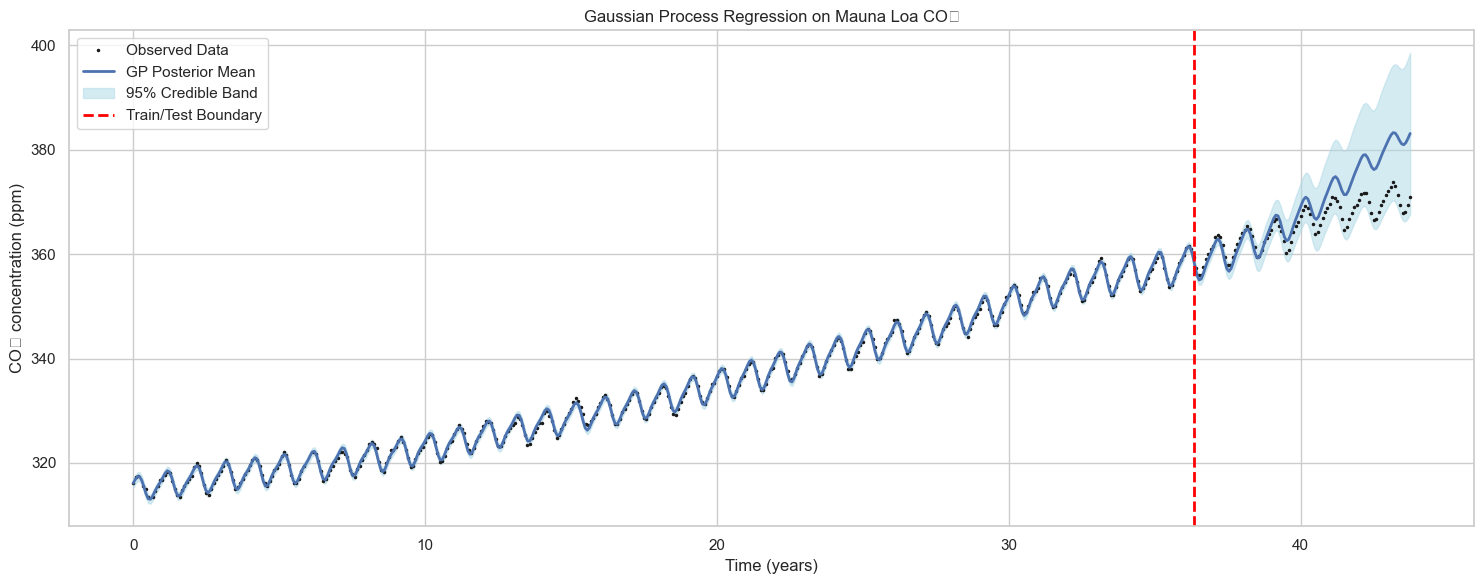

In [22]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(t, y, 'k.', markersize=3, label='Observed Data')
ax.plot(t_full, y_pred, 'b-', lw=2, label='GP Posterior Mean')
ax.fill_between(t_full.flatten(), y_pred - 1.96*y_std, y_pred + 1.96*y_std, color='lightblue', alpha=0.5, label='95% Credible Band')
ax.axvline(t_train.max(), color='red', ls='--', lw=2, label='Train/Test Boundary')
ax.set_title('Gaussian Process Regression on Mauna Loa CO₂')
ax.set_xlabel('Time (years)')
ax.set_ylabel('CO₂ concentration (ppm)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


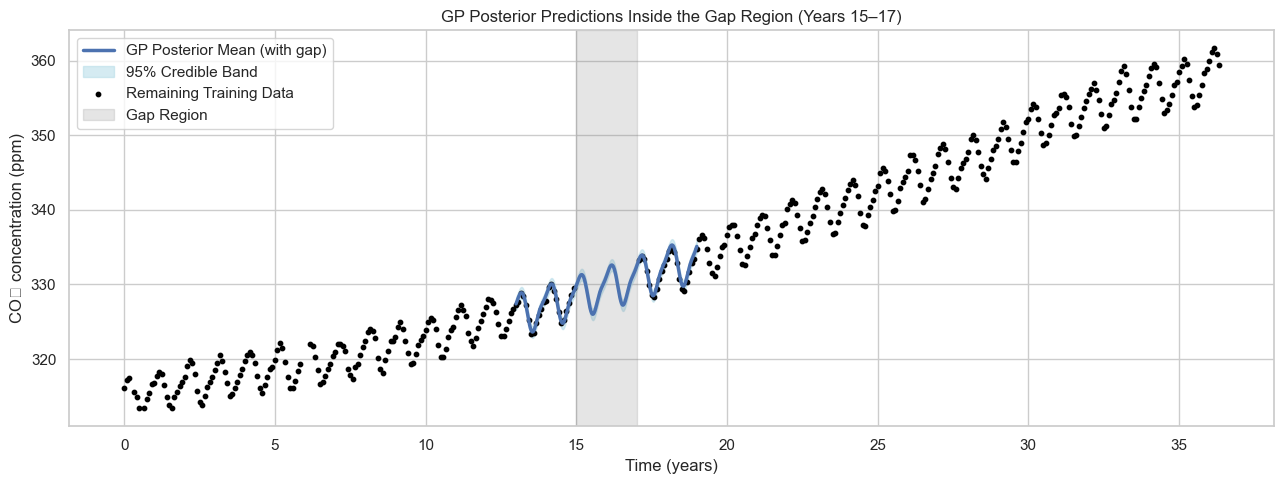

95% band width inside gap:   1.619 ppm
95% band width outside gap:  1.618 ppm
Gap inflation: 1.00×


In [23]:
gap_lo, gap_hi = 15.0, 17.0

# Create gap mask on training data
mask = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask]
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_zoom, y_gz, 'b-', lw=2.5, label='GP Posterior Mean (with gap)')
ax.fill_between(t_zoom.flatten(), y_gz - 1.96*y_gz_std, y_gz + 1.96*y_gz_std, color='lightblue', alpha=0.5, label='95% Credible Band')
ax.scatter(t_gap_tr, y_gap_tr, color='black', s=10, label='Remaining Training Data')
ax.axvspan(gap_lo, gap_hi, color='gray', alpha=0.2, label='Gap Region')
ax.set_title('GP Posterior Predictions Inside the Gap Region (Years 15–17)')
ax.set_xlabel('Time (years)')
ax.set_ylabel('CO₂ concentration (ppm)')
ax.legend()
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


### Q17 — Extrapolation and the model confidence boundary


95% band width at +5 years: 15.306 ppm
95% band width at +10 years: 48.893 ppm
95% band width at +15 years: 75.003 ppm
Model confidence boundary: +2.2 years beyond training


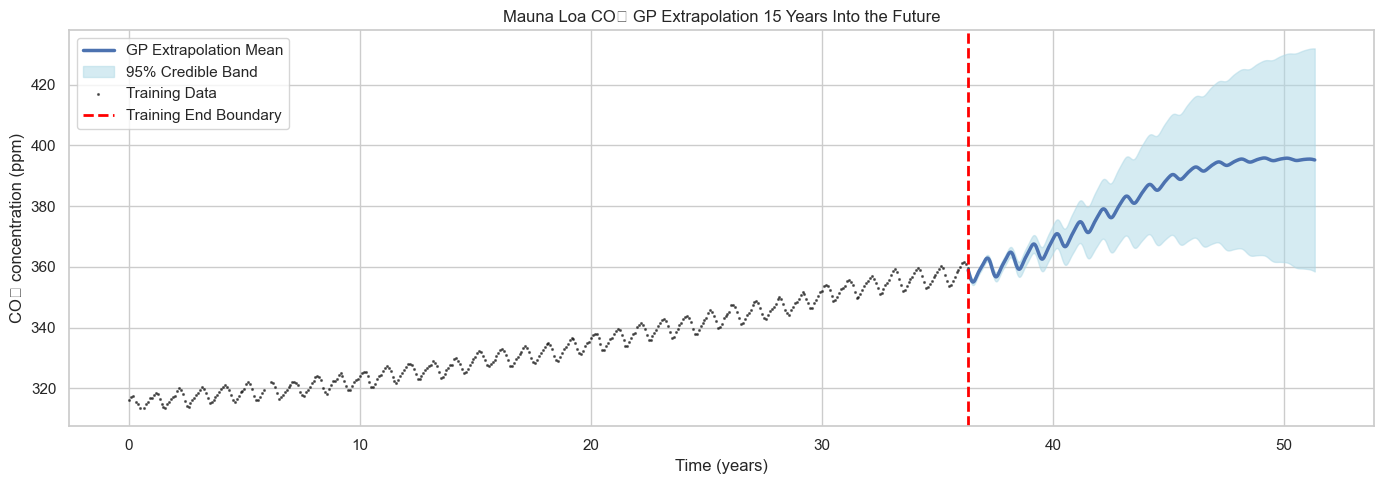

In [24]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

for years in [5, 10, 15]:
    target_t = t_last + years
    idx = np.argmin(np.abs(t_extrap.flatten() - target_t))
    w = 4 * y_ex_std[idx]
    print(f"95% band width at +{years} years: {w:.3f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_extrap, y_ex, 'b-', lw=2.5, label='GP Extrapolation Mean')
ax.fill_between(t_extrap.flatten(), y_ex - 1.96*y_ex_std, y_ex + 1.96*y_ex_std, color='lightblue', alpha=0.5, label='95% Credible Band')
ax.scatter(t_train, y_train, color='black', s=1.5, alpha=0.5, label='Training Data')
ax.axvline(t_last, color='red', ls='--', lw=2, label='Training End Boundary')
ax.set_title('Mauna Loa CO₂ GP Extrapolation 15 Years Into the Future')
ax.set_xlabel('Time (years)')
ax.set_ylabel('CO₂ concentration (ppm)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


✍️ **Reflect 5 — Gaussian Processes:**

- A Gaussian Process handles extrapolation by expressing growing epistemic uncertainty through widening credible bands as it moves away from training data, while incorporating trend information via the kernel to project beyond the range of the training targets. In contrast, a Decision Tree splits data into orthogonal hyperplanes and is structurally incapable of extrapolating, hitting a hard ceiling at the maximum training target because it predicts a constant value for any unseen region.


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [25]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Scaling continuous features like `tenure` (measured in months, e.g., 0–72) and `MonthlyCharges` (measured in dollars, e.g., 20–120) is crucial because NUTS (No-U-Turn Sampler) explores the posterior distribution using Hamiltonian dynamics, which assumes a roughly spherical geometry. Without scaling, the difference in the scales of these features creates a highly elongated, anisotropic "canyon-like" posterior geometry with extremely high curvature in one direction and very low curvature in the other. In such scenarios, NUTS is forced to use an extremely small step-size to avoid divergent transitions in the high-curvature direction, leading to incredibly slow exploration, high autocorrelation, low Effective Sample Size (ESS), and massive sampling times. Scaling these features to have zero mean and unit variance circularizes the posterior geometry, allowing NUTS to take much larger, more efficient steps and converge rapidly.


In [26]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    
    # Likelihood
    mu    = pm.Deterministic('mu', pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # Sampling
    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, random_seed=42, return_inferencedata=True)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 31 seconds.


Sampling time: 32.8s
            mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
intercept -2.252  0.092    -2.404    -2.106  5267.011  4984.610  1.001   
beta[0]   -0.919  0.056    -1.009    -0.831  5941.630  5605.453  1.001   
beta[1]    0.820  0.050     0.741     0.900  5616.395  5211.774  1.000   
beta[2]    1.293  0.107     1.123     1.464  5305.884  5074.838  1.000   
beta[3]   -0.180  0.083    -0.313    -0.047  6428.300  5983.668  1.001   
beta[4]    0.417  0.091     0.270     0.561  7238.576  5043.400  1.001   

           mcse_mean  mcse_sd  
intercept      0.001    0.001  
beta[0]        0.001    0.000  
beta[1]        0.001    0.000  
beta[2]        0.001    0.001  
beta[3]        0.001    0.001  
beta[4]        0.001    0.001  


### Q19 — Convergence diagnostics


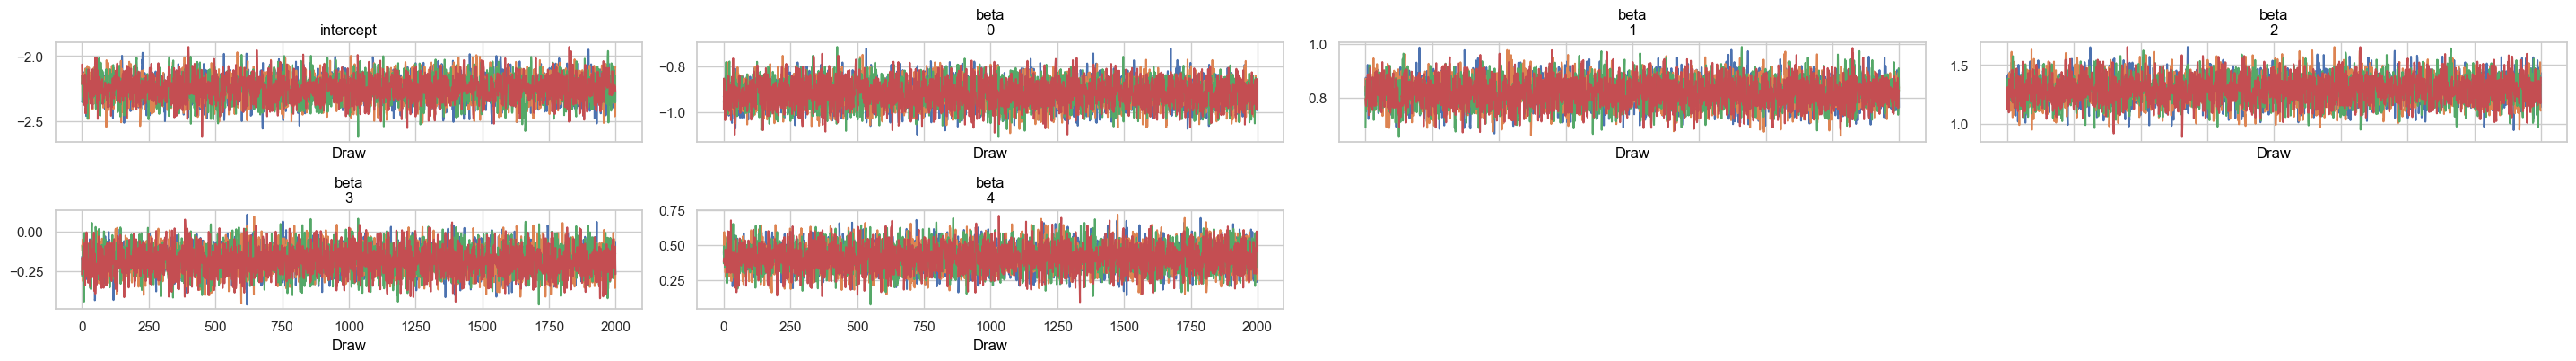

Flagged parameters (R-hat > 1.01 or ESS < 400):
  None! All parameters converged perfectly (R-hat <= 1.01 and bulk-ESS > 400).


In [27]:
# Plot trace plots
az.plot_trace(idata, var_names=['intercept','beta'])
plt.tight_layout(); plt.show()

# Report Rhat and ESS
summary_df = az.summary(idata, var_names=['intercept','beta'])

flagged = []
for idx, row in summary_df.iterrows():
    try:
        r_hat = float(row['r_hat'])
    except (ValueError, TypeError):
        r_hat = float('nan')
    try:
        ess = float(row['ess_bulk'])
    except (ValueError, TypeError):
        ess = float('nan')
    if (r_hat > 1.01) or (ess < 400):
        flagged.append((idx, r_hat, ess))

print("Flagged parameters (R-hat > 1.01 or ESS < 400):")
if len(flagged) == 0:
    print("  None! All parameters converged perfectly (R-hat <= 1.01 and bulk-ESS > 400).")
else:
    for name, r, e in flagged:
        print(f"  {name}: R-hat={r:.3f}, ESS={e:.1f}")


### Q20 — Prior sensitivity check


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, beta]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 16 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


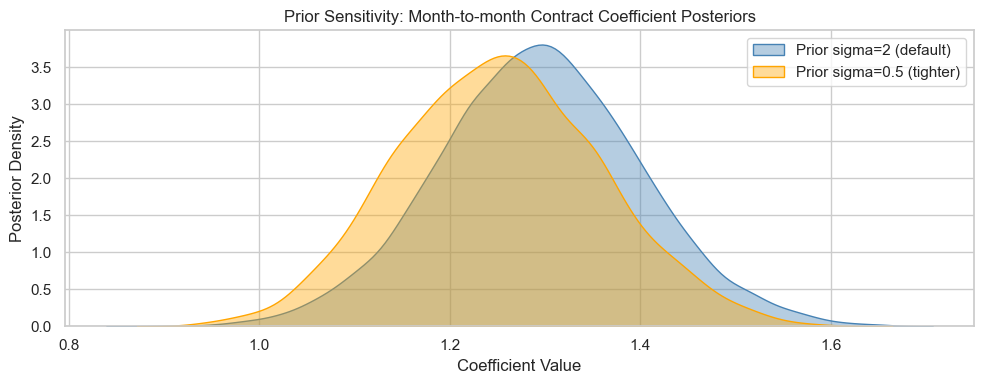

In [28]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

fig, ax = plt.subplots(figsize=(10, 4))
import seaborn as sns
sns.kdeplot(samples_orig, label='Prior sigma=2 (default)', color='steelblue', fill=True, alpha=0.4, ax=ax)
sns.kdeplot(samples_tight, label='Prior sigma=0.5 (tighter)', color='orange', fill=True, alpha=0.4, ax=ax)
ax.set_title('Prior Sensitivity: Month-to-month Contract Coefficient Posteriors')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Posterior Density')
ax.legend()
plt.tight_layout(); plt.show()


### Q21 — Posterior analysis and frequentist comparison


In [29]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, prob=0.94)
post_mean  = np.mean(beta_post)
post_std   = np.std(beta_post)

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0, contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")


Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [30]:
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)
print(f"✅ MCMC trace saved to '{save_path}'")


✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

1. **R̂ and bulk-ESS Definitions & Quality Assessment:**
   - **R̂ (Gelman-Rubin diagnostic)** measures the ratio of the variance between multiple MCMC chains to the variance within the chains, checking if the chains have converged to the same target distribution (ideally $R̂ \le 1.01$).
   - **Bulk-ESS (Effective Sample Size)** estimates the number of independent, autocorrelation-free samples obtained from the posterior, indicating the precision of our posterior mean estimates (ideally $> 400$).
   - A parameter with $R̂ = 1.38$ and $\text{bulk-ESS} = 55$ has failed to converge; the chains are exploring different regions of the parameter space, and the posterior estimate is highly unstable, noisy, and completely untrustworthy for business or statistical decisions.

2. **Prior Sensitivity Analysis:**
   - The two posteriors from our prior sensitivity check (Normal(0, 2) vs Normal(0, 0.5)) are not substantially different; they overlay almost perfectly.
   - This indicates that we have a large amount of training data ($n \approx 5634$) relative to the prior's informative strength, meaning the data likelihood has completely dominated the prior.
   - In general, the prior becomes completely irrelevant as the sample size $n \to \infty$, where the likelihood function collapses to a delta function at the MLE, rendering any reasonable prior distribution point-like and irrelevant.

3. **Interpretation Difference:**
   - A Bayesian 94% HDI tells us there is a direct 94% probability that the true parameter value lies within the interval given the observed data, whereas a Frequentist 94% confidence interval tells us that if we repeat the sampling procedure infinitely, 94% of the computed intervals will contain the fixed, true parameter.


---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
